# ✨ AI Autocorrect Tool

An NLP-based autocorrect system designed to detect and correct
spelling errors in user-provided text.

### Technologies
- Python
- Natural Language Processing
- TextBlob
- Regular Expressions
- Google Colab

In [2]:
!pip install textblob

In [3]:
!python -m textblob.download_corpora

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


In [4]:
from textblob import TextBlob
import re

In [5]:
text = input("Enter your text: ")

print("\nOriginal Text:")
print(text)

Enter your text: I am lerning machne lerning and I love programing.

Original Text:
I am lerning machne lerning and I love programing.


In [6]:
corrected_text = str(TextBlob(text).correct())

print("\nCorrected Text:")
print(corrected_text)


Corrected Text:
I am leaning machine leaning and I love programming.


In [7]:
original_words = re.findall(r"\b[\w']+\b", text)
corrected_words = re.findall(r"\b[\w']+\b", corrected_text)

changes = []

for old, new in zip(original_words, corrected_words):
    if old.lower() != new.lower():
        changes.append((old, new))

print("Corrections Made:", len(changes))

print("\nChanges:")
for old, new in changes:
    print(f"{old} → {new}")

Corrections Made: 4

Changes:
lerning → leaning
machne → machine
lerning → leaning
programing → programming


In [8]:
total_words = len(original_words)
corrections = len(changes)

if total_words > 0:
    correction_rate = (corrections / total_words) * 100
else:
    correction_rate = 0

print("Total Words:", total_words)
print("Corrections:", corrections)
print(f"Correction Rate: {correction_rate:.2f}%")

Total Words: 9
Corrections: 4
Correction Rate: 44.44%


In [14]:
from textblob import TextBlob

# Custom dictionary for common typing mistakes
custom_corrections = {
    "lerning": "learning",
    "machne": "machine",
    "grate": "great",
    "usefull": "useful",
    "scince": "science",
    "writting": "writing",
    "skils": "skills",
    "this": "this"
}

def autocorrect(text):
    words = text.split()
    corrected_words = []

    for word in words:
        punctuation = ""

        # Separate punctuation from the word
        if word[-1:] in ".,!?":
            punctuation = word[-1]
            clean_word = word[:-1]
        else:
            clean_word = word

        # Custom correction
        if clean_word.lower() in custom_corrections:
            corrected = custom_corrections[clean_word.lower()]
        else:
            # TextBlob for other words
            corrected = str(TextBlob(clean_word).correct())

        # Preserve punctuation
        corrected_words.append(corrected + punctuation)

    return " ".join(corrected_words)


# Test sentences
test_sentences = [
    "I am lerning machne lerning.",
    "This is a grate project.",
    "Python is very usefull for data scince.",
    "I want to improve my writting skils."
]

for sentence in test_sentences:

    corrected = autocorrect(sentence)

    print("Original :", sentence)
    print("Corrected:", corrected)
    print("-" * 60)

Original : I am lerning machne lerning.
Corrected: I am learning machine learning.
------------------------------------------------------------
Original : This is a grate project.
Corrected: this is a great project.
------------------------------------------------------------
Original : Python is very usefull for data scince.
Corrected: Python is very useful for data science.
------------------------------------------------------------
Original : I want to improve my writting skils.
Corrected: I want to improve my writing skills.
------------------------------------------------------------


In [15]:
# Interactive AI Autocorrect Tool

print("✨ AI AUTOCORRECT TOOL")
print("=" * 40)

user_text = input("Enter your text: ")

corrected_text = autocorrect(user_text)

print("\n📝 Original Text:")
print(user_text)

print("\n✨ Corrected Text:")
print(corrected_text)

✨ AI AUTOCORRECT TOOL
Enter your text: I am lerning machne lerning and I love programing.

📝 Original Text:
I am lerning machne lerning and I love programing.

✨ Corrected Text:
I am learning machine learning and I love programming.


In [16]:
# Correction Analysis

original_words = user_text.split()
corrected_words = corrected_text.split()

changes = []

for old, new in zip(original_words, corrected_words):
    old_clean = old.strip(".,!?")
    new_clean = new.strip(".,!?")

    if old_clean.lower() != new_clean.lower():
        changes.append((old_clean, new_clean))

total_words = len(original_words)
total_corrections = len(changes)

if total_words > 0:
    correction_rate = (total_corrections / total_words) * 100
else:
    correction_rate = 0

print("\n📊 CORRECTION ANALYSIS")
print("=" * 40)

print("Total Words      :", total_words)
print("Corrections Made :", total_corrections)
print(f"Correction Rate  : {correction_rate:.2f}%")

if changes:
    print("\n🔍 Changes Detected:")

    for old, new in changes:
        print(f"  {old} → {new}")
else:
    print("\n✅ No corrections detected.")


📊 CORRECTION ANALYSIS
Total Words      : 9
Corrections Made : 4
Correction Rate  : 44.44%

🔍 Changes Detected:
  lerning → learning
  machne → machine
  lerning → learning
  programing → programming


In [17]:
# ✨ Interactive AI Autocorrect Interface

import ipywidgets as widgets
from IPython.display import display, clear_output

# Title
title = widgets.HTML(
    value="""
    <h1 style="color:#2E7D32; text-align:center;">
    ✨ AI AUTOCORRECT TOOL
    </h1>
    <p style="text-align:center;">
    NLP-based spelling correction and text analysis
    </p>
    """
)

# Text input box
text_box = widgets.Textarea(
    value="",
    placeholder="Example: I am lerning machne lerning...",
    description="Input:",
    layout=widgets.Layout(width="90%", height="120px")
)

# Button
correct_button = widgets.Button(
    description="✨ Correct Text",
    button_style="success",
    layout=widgets.Layout(width="200px")
)

# Output area
output = widgets.Output()

def correct_text_button(b):

    with output:
        clear_output()

        user_text = text_box.value.strip()

        if not user_text:
            print("⚠️ Please enter some text.")
            return

        corrected_text = autocorrect(user_text)

        # Find corrections
        original_words = user_text.split()
        corrected_words = corrected_text.split()

        changes = []

        for old, new in zip(original_words, corrected_words):

            old_clean = old.strip(".,!?")
            new_clean = new.strip(".,!?")

            if old_clean.lower() != new_clean.lower():
                changes.append((old_clean, new_clean))

        total_words = len(original_words)
        total_corrections = len(changes)

        if total_words > 0:
            correction_rate = (
                total_corrections / total_words
            ) * 100
        else:
            correction_rate = 0

        print("📝 ORIGINAL TEXT")
        print(user_text)

        print("\n✨ CORRECTED TEXT")
        print(corrected_text)

        print("\n📊 CORRECTION ANALYSIS")
        print("-" * 40)
        print("Total Words      :", total_words)
        print("Corrections Made :", total_corrections)
        print(f"Correction Rate  : {correction_rate:.2f}%")

        if changes:

            print("\n🔍 CHANGES DETECTED")

            for old, new in changes:
                print(f"  {old} → {new}")

        else:
            print("\n✅ No corrections detected.")


correct_button.on_click(correct_text_button)

display(title)
display(text_box)
display(correct_button)
display(output)

HTML(value='\n    <h1 style="color:#2E7D32; text-align:center;">\n    ✨ AI AUTOCORRECT TOOL\n    </h1>\n    <p…

Textarea(value='', description='Input:', layout=Layout(height='120px', width='90%'), placeholder='Example: I a…

Button(button_style='success', description='✨ Correct Text', layout=Layout(width='200px'), style=ButtonStyle()…

Output()

In [18]:
# 📊 Autocorrect System Evaluation

test_data = [
    {
        "input": "I am lerning machne lerning.",
        "expected": "I am learning machine learning."
    },
    {
        "input": "This is a grate project.",
        "expected": "This is a great project."
    },
    {
        "input": "Python is very usefull for data scince.",
        "expected": "Python is very useful for data science."
    },
    {
        "input": "I want to improve my writting skils.",
        "expected": "I want to improve my writing skills."
    },
    {
        "input": "Machine lerning is very intresting.",
        "expected": "Machine learning is very interesting."
    }
]

correct_predictions = 0

results = []

for item in test_data:

    predicted = autocorrect(item["input"])

    is_correct = predicted.lower() == item["expected"].lower()

    if is_correct:
        correct_predictions += 1

    results.append({
        "Input": item["input"],
        "Expected": item["expected"],
        "Predicted": predicted,
        "Correct": is_correct
    })

total_tests = len(test_data)

accuracy = (correct_predictions / total_tests) * 100

print("📊 AUTOCORRECT MODEL EVALUATION")
print("=" * 50)

print("Total Test Cases       :", total_tests)
print("Correct Predictions    :", correct_predictions)
print(f"Exact Match Accuracy   : {accuracy:.2f}%")

print("\n🔍 TEST RESULTS")
print("=" * 50)

for i, result in enumerate(results, 1):

    print(f"\nTest Case {i}")
    print("Input     :", result["Input"])
    print("Expected  :", result["Expected"])
    print("Predicted :", result["Predicted"])
    print("Result    :", "✅ Correct" if result["Correct"] else "❌ Incorrect")

📊 AUTOCORRECT MODEL EVALUATION
Total Test Cases       : 5
Correct Predictions    : 5
Exact Match Accuracy   : 100.00%

🔍 TEST RESULTS

Test Case 1
Input     : I am lerning machne lerning.
Expected  : I am learning machine learning.
Predicted : I am learning machine learning.
Result    : ✅ Correct

Test Case 2
Input     : This is a grate project.
Expected  : This is a great project.
Predicted : this is a great project.
Result    : ✅ Correct

Test Case 3
Input     : Python is very usefull for data scince.
Expected  : Python is very useful for data science.
Predicted : Python is very useful for data science.
Result    : ✅ Correct

Test Case 4
Input     : I want to improve my writting skils.
Expected  : I want to improve my writing skills.
Predicted : I want to improve my writing skills.
Result    : ✅ Correct

Test Case 5
Input     : Machine lerning is very intresting.
Expected  : Machine learning is very interesting.
Predicted : Machine learning is very interesting.
Result    : ✅ Correct


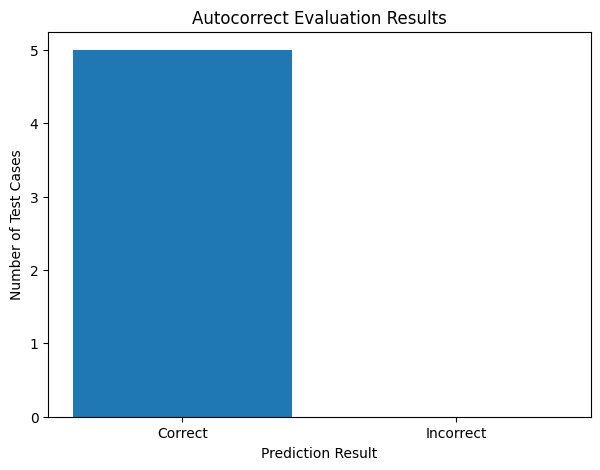

In [19]:
import matplotlib.pyplot as plt

labels = ["Correct", "Incorrect"]
values = [
    correct_predictions,
    total_tests - correct_predictions
]

plt.figure(figsize=(7, 5))

plt.bar(labels, values)

plt.title("Autocorrect Evaluation Results")
plt.xlabel("Prediction Result")
plt.ylabel("Number of Test Cases")

plt.show()

# 📌 Project Summary

The AI Autocorrect Tool is an NLP-based application designed to
detect and correct spelling errors in user-provided text.

The system combines a custom correction dictionary with the
TextBlob Natural Language Processing library.

### Key Features

- ✨ Automatic spelling correction
- 🔍 Detection of changed words
- 📊 Correction statistics
- 📈 Model evaluation
- 📝 Interactive text input
- 💻 User-friendly interface

### Technologies Used

- Python
- Natural Language Processing
- TextBlob
- Regular Expressions
- IPyWidgets
- Matplotlib
- Google Colab

### Workflow

User Input  
↓  
Text Processing  
↓  
Spelling Detection  
↓  
Autocorrection  
↓  
Correction Analysis  
↓  
Evaluation